In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic

In [2]:
# Load dataset
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# 1. Überblick über den Datensatz

Der Datensatz **tips** enthält Informationen zu Restaurantbesuchen:
- Höhe der Rechnung (`total_bill`)
- Höhe des Trinkgelds (`tip`)
- Geschlecht des Servierenden (`sex`)
- Raucherstatus (`smoker`)
- Wochentag (`day`)
- Tageszeit (`time`)
- Gruppengröße (`size`)

Ziel: Erkennen, welche Visualisierungen und statistischen Tests für unterschiedliche Kombinationen von Variablen geeignet sind.

In [3]:
df.shape

(244, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [5]:
# Fehlende Werte?

df.isna().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [6]:
# Neue Variablen bilden

df['tip_pct'] = df['tip'] / df['total_bill']

In [7]:
df.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447
1,10.34,1.66,Male,No,Sun,Dinner,3,0.160542
2,21.01,3.50,Male,No,Sun,Dinner,3,0.166587
3,23.68,3.31,Male,No,Sun,Dinner,2,0.139780
4,24.59,3.61,Female,No,Sun,Dinner,4,0.146808


# 2. Variablentypen bestimmen

Unterscheide zwischen:
- **Kategorialen Variablen:** diskrete Gruppen (z. B. `sex`, `day`, `smoker`)
- **Stetigen Variablen:** numerische Werte mit vielen Ausprägungen (z. B. `total_bill`, `tip`)

Ordne die wichtigsten Variablen den Typen zu:
| Variable | Typ | Beschreibung |
|-----------|-----|--------------|
| sex | kategorial | Geschlecht der Bedienung |
| smoker | kategorial | Raucher ja/nein |
| day | kategorial | Tag des Restaurantbesuchs |
| time | kategorial | Mittag oder Abend |
| total_bill | stetig | Gesamtrechnung in USD |
| tip | stetig | Trinkgeld in USD |
| size | quasi-stetig | Gruppengröße |

In [8]:
# Deskriptive Kennzahlen für alle Variablen

df.describe(include="all")

,total_bill,tip,sex,smoker,day,time,size,tip_pct
count,244.000000,244.000000,244,244,244,244,244.000000,244.000000
unique,NaN,NaN,2,2,4,2,NaN,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN,NaN
freq,NaN,NaN,157,151,87,176,NaN,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672,0.160803
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100,0.061072
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000,0.035638
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000,0.129127
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000,0.154770
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000,0.191475


## Stetige Variablen beschreiben und visualisieren

### Was sind stetige Variablen?
Stetige (metrische) Variablen sind **numerische Messgrößen**, die beliebig viele Werte annehmen können.  
Beispiele im `tips`-Datensatz:
- Rechnungsbetrag (`total_bill`)
- Trinkgeld (`tip`)
- Verhältnis Trinkgeld zu Rechnung (`tip_pct`)

---

### Kennzahlen berechnen

```python
df["total_bill"].describe()"].describe()


In [9]:
df["total_bill"].mean(), df["total_bill"].median(), df["total_bill"].std()

(19.78594262295082, 17.795, 8.902411954856856)

In [10]:
df["total_bill"].describe()

count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64

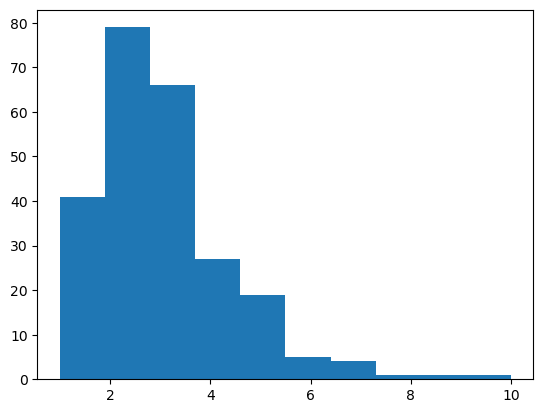

In [11]:
plt.hist(df["tip"]);

<Axes: xlabel='tip', ylabel='Count'>

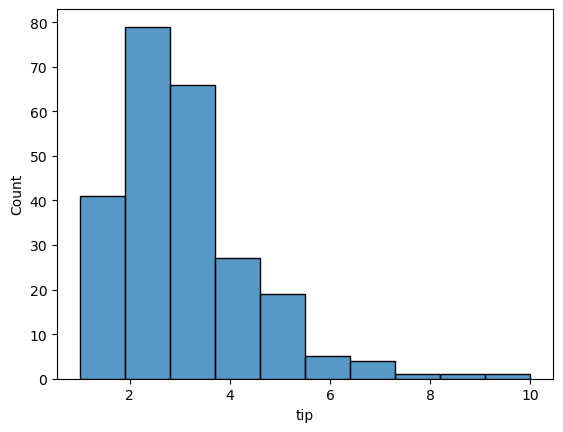

In [12]:
sns.histplot(data=df, x="tip", bins=10)

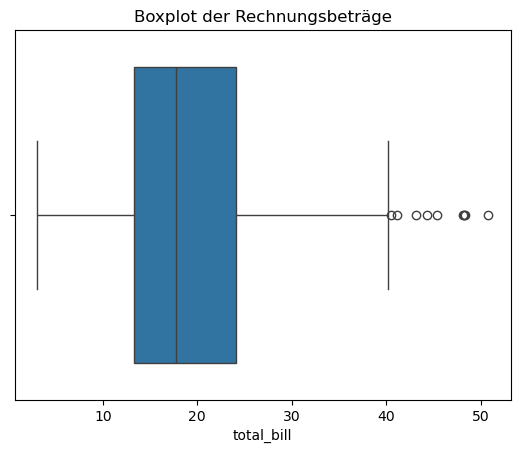

In [13]:
sns.boxplot(x=df['total_bill'])
plt.title("Boxplot der Rechnungsbeträge")
plt.show()

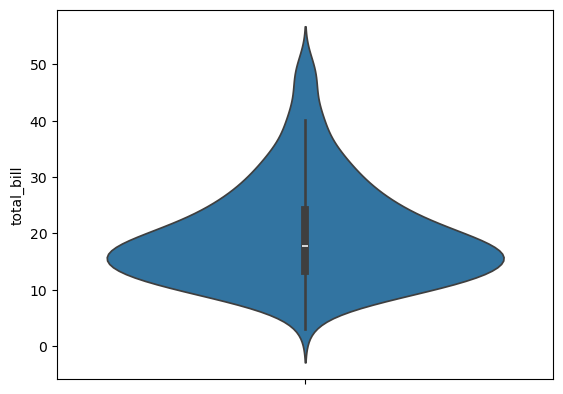

In [14]:
sns.violinplot(y=df['total_bill'])
plt.show()

### Interpretation stetiger Variablen

- **Histogramm** zeigt die **Form der Verteilung** (z. B. symmetrisch, rechtsschief, linksschief).  
- **Boxplot** zeigt **Lage und Streuung** (Median, Quartile, Ausreißer).  
- **Violinplot** kombiniert Boxplot und Dichte – man erkennt, wo Werte **häufig oder selten** sind.  
- Anhand von **Mittelwert und Median** lässt sich prüfen, ob die Verteilung **symmetrisch** ist.  
- **Ausreißer** deuten auf einzelne ungewöhnlich hohe oder niedrige Werte hin.  
- Geld- oder Zeitdaten sind oft **rechtsschief**: viele kleine, wenige große Werte.


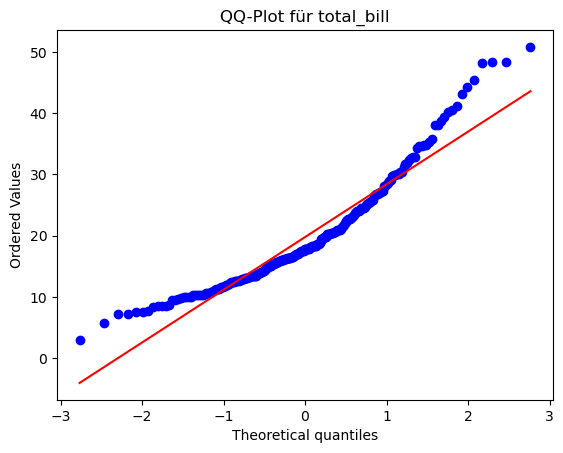

In [15]:
stats.probplot(df['total_bill'], dist="norm", plot=plt)
plt.title("QQ-Plot für total_bill")
plt.show()

In [16]:
stats.shapiro(df['total_bill'])

ShapiroResult(statistic=0.9197187941346584, pvalue=3.3245391868090786e-10)

### Warum prüft man die Normalverteilung?

Viele **statistische Tests** (z. B. t-Test, ANOVA, lineare Regression) setzen voraus,  
dass die untersuchten metrischen Variablen **annähernd normalverteilt** sind.  

Durch den **QQ-Plot** und Tests wie den **Shapiro-Wilk-Test** kann man prüfen,  
ob diese Annahme erfüllt ist.  

- Wenn die Daten **normalverteilt** sind → parametrische Tests (z. B. t-Test) sind zulässig.  
- Wenn sie **deutlich abweichen** → besser **nichtparametrische Tests** verwenden  
  (z. B. Mann-Whitney-U-Test oder Wilcoxon-Test).  

Die Normalitätsprüfung hilft also, **das passende Testverfahren** auszuwählen.


### Interpretation QQ-Plot und Shapiro-Wilk-Test

- **QQ-Plot:** Die Punkte weichen im oberen Bereich deutlich von der roten Linie ab → die Verteilung hat **mehr große Werte** als eine Normalverteilung (rechtsschief).  
- **Shapiro-Wilk-Test:** p-Wert = 3.3e-10 < 0.05 → die Annahme einer **Normalverteilung wird verworfen**.  
- Fazit: `total_bill` ist **nicht normalverteilt**, sondern zeigt eine **rechtsschiefe Verteilung** mit einigen größeren Rechnungsbeträgen.


## Kategoriale Variablen beschreiben und visualisieren

### Was sind kategoriale Variablen?
Kategoriale Variablen beschreiben **Merkmale mit wenigen festen Ausprägungen**, z. B.  
- Geschlecht (`sex`),  
- Raucherstatus (`smoker`),  
- Wochentag (`day`),  
- Essenszeit (`time`).  

Sie können **nominal** (keine Reihenfolge, z. B. Geschlecht) oder **ordinal** (mit Reihenfolge, z. B. Schulnoten) sein.

---

### Häufigkeiten und Anteile

```python
df["sex"].value_counts()
df["sex"].value_counts(normalize=True) * 100lize=True) * 100


In [17]:
df['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [18]:
df['sex'].value_counts(normalize=True).round(2)

sex
Male      0.64
Female    0.36
Name: proportion, dtype: float64

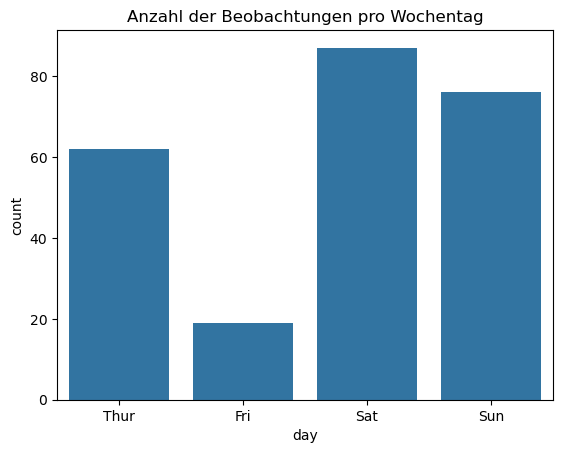

In [19]:
sns.countplot(x="day", data=df)
plt.title("Anzahl der Beobachtungen pro Wochentag")
plt.show()

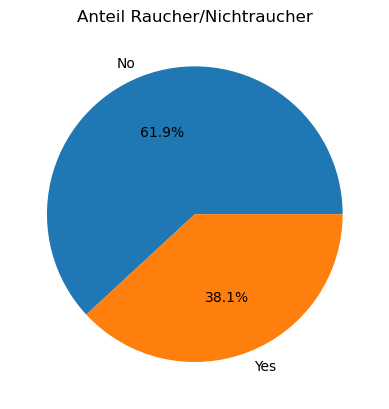

In [20]:
df["smoker"].value_counts().plot.pie(autopct="%.1f%%")
plt.title("Anteil Raucher/Nichtraucher")
plt.ylabel("")
plt.show()

## 3. Kombination 1: Zwei kategoriale Variablen
Beispiel: **`sex` × `smoker`**

**Fragestellung:**  
Gibt es einen Zusammenhang zwischen Geschlecht und Raucherstatus?

---

### Warum ist das interessant?
Kategoriale Variablen werden oft gemeinsam betrachtet, um zu prüfen,  
ob **die Verteilung der einen Variable von der anderen abhängt**.  
→ z. B. Rauchen Männer häufiger als Frauen?

---

### Häufigkeiten (Kreuztabelle)

```python
pd.crosstab(df["sex"], df["smoker"])
pd.crosstab(df["sex"], df["smoker"], margins=True, normalize="index") * 100


In [21]:
# Kreuztabelle
pd.crosstab(df['sex'], df['smoker'], margins=True)

smoker,Yes,No,All
sex,,,
Male,60,97,157
Female,33,54,87
All,93,151,244


In [22]:
# Kreuztabelle
pd.crosstab(df['sex'], df['smoker'], margins=True, normalize="index")

smoker,Yes,No
sex,,
Male,0.382166,0.617834
Female,0.379310,0.620690
All,0.381148,0.618852


### Interpretation der Kreuztabelle (`sex` × `smoker`)

- Insgesamt wurden **244 Personen** erfasst: 157 Männer und 87 Frauen.  
- **60 Männer (≈38 %)** und **33 Frauen (≈38 %)** sind Raucher.  
- Der Anteil der Raucher ist bei Männern und Frauen **nahezu gleich**.  
- Damit gibt es **keinen auffälligen Unterschied** im Rauchverhalten zwischen den Geschlechtern.  

**Fazit:**  
Die Kreuztabelle zeigt, dass Geschlecht und Raucherstatus in diesem Datensatz **unabhängig voneinander** zu sein scheinen.  
Eine formale Prüfung erfolgt anschließend mit dem **Chi²-Unabhängigkeitstest**.


## Visualisierungen

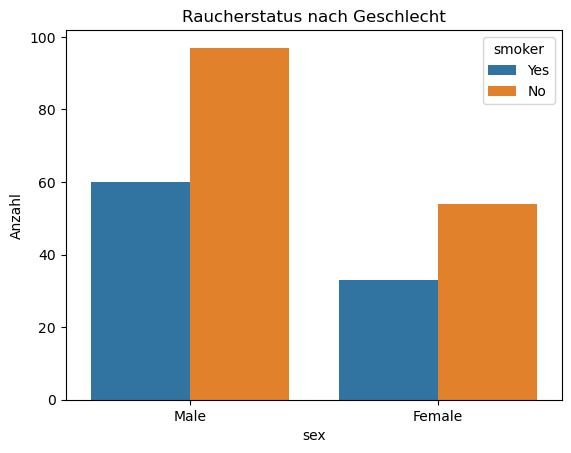

In [23]:
sns.countplot(x="sex", hue="smoker", data=df)
plt.title("Raucherstatus nach Geschlecht")
plt.ylabel("Anzahl")
plt.show()

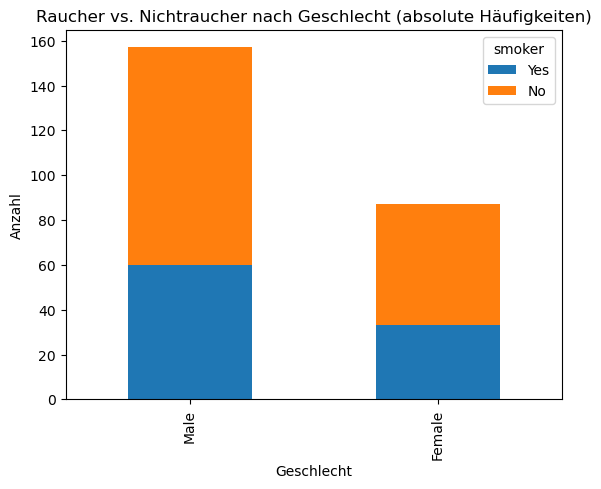

In [24]:
ct = pd.crosstab(df['sex'], df['smoker'])

ct.plot(kind='bar', stacked=True)
plt.title("Raucher vs. Nichtraucher nach Geschlecht (absolute Häufigkeiten)")
plt.xlabel("Geschlecht")
plt.ylabel("Anzahl")
plt.show()

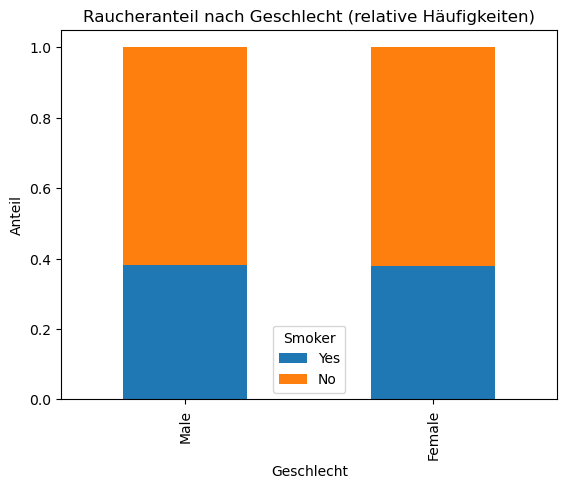

In [25]:
ct_rel = pd.crosstab(df['sex'], df['smoker'], normalize='index')

ct_rel.plot(kind='bar', stacked=True)
plt.title("Raucheranteil nach Geschlecht (relative Häufigkeiten)")
plt.xlabel("Geschlecht")
plt.ylabel("Anteil")
plt.legend(title="Smoker")
plt.show()

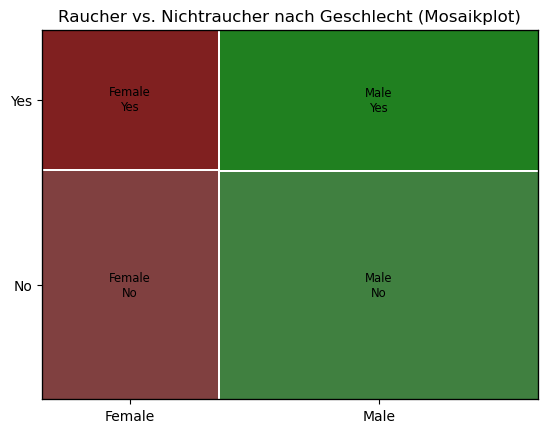

In [26]:
# Mosaikplot zeichnen
mosaic(df, ["sex", "smoker"])
plt.title("Raucher vs. Nichtraucher nach Geschlecht (Mosaikplot)")
plt.show()

## Hypothesentest

## Exkurs: Der Chi²-Unabhängigkeitstest

### 1. Ziel
Der Chi²-Test prüft, ob **zwei kategoriale Variablen** voneinander **abhängen**  
oder **unabhängig** sind.

**Beispiel:**  
Unterscheidet sich der Raucheranteil zwischen Männern und Frauen?

---

### 2. Grundidee
- Wir beobachten eine **Kreuztabelle** mit Häufigkeiten.  
- Wenn die Variablen **unabhängig** wären, ließen sich die Zellhäufigkeiten  
  aus den Randverteilungen **erwarten** (erwartete Häufigkeiten).  
- Der Chi²-Test misst, **wie stark** die beobachteten Häufigkeiten  
  von diesen erwarteten abweichen.

\[
\chi^2 = \sum \frac{(O - E)^2}{E}
\]

- \(O\): beobachtete Häufigkeit  
- \(E\): erwartete Häufigkeit unter der Annahme der Unabhängigkeit

Je größer die Abweichungen, desto größer \(\chi^2\) → desto unwahrscheinlicher ist Unabhängigkeit.

---

### 3. Hypothesen

- **H₀ (Nullhypothese):** Die Variablen sind **unabhängig**.  
- **H₁ (Alternativhypothese):** Es besteht ein **Zusammenhang**.

---

### 4. Entscheidung
- Wenn **p < 0.05** → H₀ verwerfen → es gibt **einen signifikanten Zusammenhang**.  
- Wenn **p ≥ 0.05** → H₀ beibehalten → **kein nachweisbarer Zusammenhang**.

---

### 5. Effektstärke
Mit **Cramér’s V** kann man die **Stärke** des Zusammenhangs bestimmen:

| Cramér’s V | Interpretation |
|-------------|----------------|
| 0.1 | schwach |
| 0.3 | mittel |
| 0.5 | stark |

---

### 6. Voraussetzungen
- Beide Variablen sind **kategorial**.  
- Erwartete Häufigkeiten in jeder Zelle möglichst **≥ 5**.  
- Beobachtungen sind **unabhängig** voneinander.

---

### 7. Kurz gesagt
Der Chi²-Test prüft, ob Unterschiede in einer Kreuztabelle **zufällig** sind  
oder auf einen **tatsächlichen Zusammenhang** zwischen den Variablen hinweisen.


In [27]:
# Kreuztabelle
contingency = pd.crosstab(df['sex'], df['smoker'])

# Chi²-Test
chi2, p, dof, expected = stats.chi2_contingency(contingency)

# Cramér’s V
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

print(f"Chi² = {chi2:.2f}, p = {p:.4f}, Cramér’s V = {cramers_v:.3f}")

Chi² = 0.00, p = 1.0000, Cramér’s V = 0.000


### Interpretation: Chi²-Test & Cramér’s V (Allgemein)

**p-Wert:**  
- Der p-Wert zeigt, wie wahrscheinlich das beobachtete Muster (oder ein extremeres) wäre, *wenn es in Wahrheit keinen Zusammenhang* zwischen den Variablen gäbe.  
- Ist der p-Wert **< 0.05**, spricht das für einen **statistisch signifikanten Zusammenhang**.  
- Ist der p-Wert **≥ 0.05**, kann der Unterschied **durch Zufall** erklärt werden – es gibt also keinen klaren Zusammenhang.

**Cramér’s V:**  
- Misst die **Stärke** des Zusammenhangs zwischen zwei kategorialen Variablen.  
- Wertebereich: **0 = kein Zusammenhang**, **1 = perfekter Zusammenhang**.  
- Faustregeln für die Stärke:
  - `V < 0.1` → sehr schwach  
  - `0.1–0.3` → schwach  
  - `0.3–0.5` → moderat  
  - `> 0.5` → stark

### Interpretation des Chi²-Tests und Cramér’s V

- **Chi² = 0.00**, **p = 1.0000** → Der p-Wert ist deutlich größer als 0.05.  
  ⇒ Die **Nullhypothese** (Geschlecht und Raucherstatus sind unabhängig) **kann nicht verworfen** werden.  
- Es gibt **keinen statistisch signifikanten Zusammenhang** zwischen Geschlecht und Raucherstatus.  

- **Cramér’s V = 0.000** → Die **Stärke des Zusammenhangs** ist praktisch **null**.  

**Fazit:**  
Im Datensatz ist das Rauchverhalten bei Männern und Frauen **gleich verteilt**.  
Geschlecht und Raucherstatus sind **unabhängig** voneinander.

## 4. Kombination 2: Eine kategoriale und eine stetige Variable
Beispiel: **`time` → `total_bill`**

**Fragestellung:**  
Unterscheiden sich die Rechnungsbeträge zwischen Mittag (`Lunch`) und Abend (`Dinner`)?

---

### Warum ist das interessant?
Wenn eine Variable **Gruppen** bildet (z. B. Tageszeit) und die andere **Messwerte** enthält (z. B. Rechnungsbetrag),  
kann man prüfen, ob sich die Gruppen **im Mittelwert** unterscheiden.

Beispiele:
- Gibt es Preisunterschiede zwischen Mittag und Abend?  
- Geben Männer im Schnitt mehr Trinkgeld als Frauen?

---

### Deskriptive Statistik nach Gruppen

```python
df.groupby("time")["total_bill"].describe()


In [28]:
df.groupby('time', observed=True)['total_bill'].mean()

time
Lunch     17.168676
Dinner    20.797159
Name: total_bill, dtype: float64

## Visualisierungen

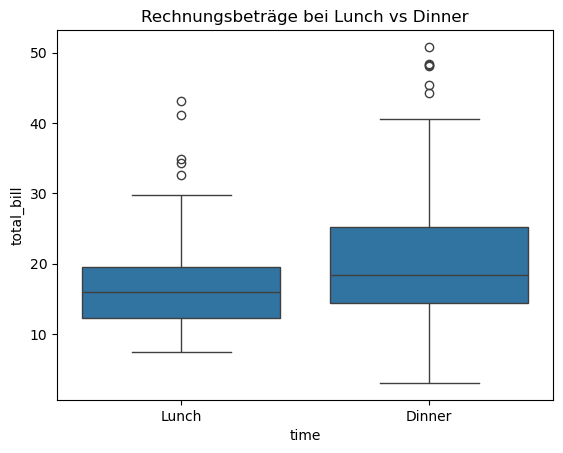

In [29]:
sns.boxplot(data=df, x="time", y="total_bill")
plt.title("Rechnungsbeträge bei Lunch vs Dinner")
plt.show()

<Axes: xlabel='time', ylabel='total_bill'>

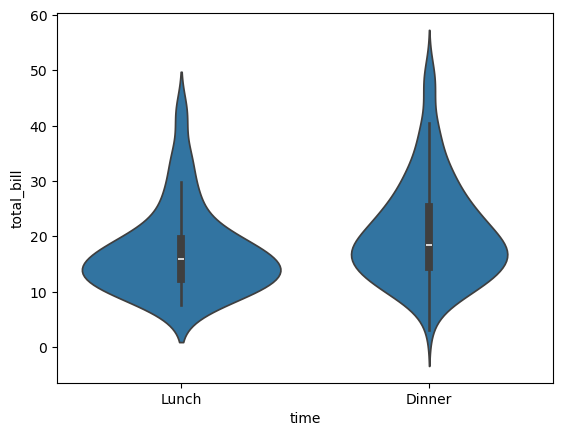

In [30]:
sns.violinplot(x="time", y="total_bill", data=df)

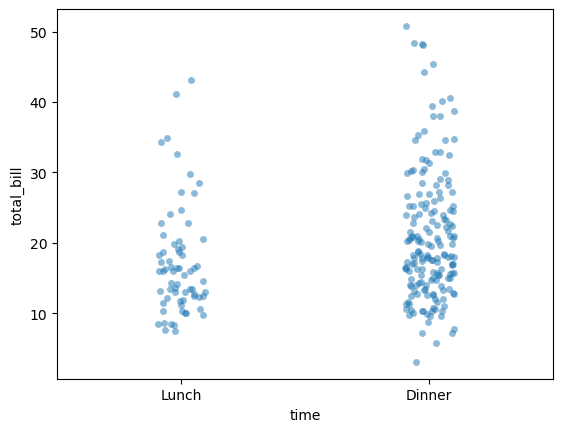

In [31]:
sns.stripplot(data=df, x="time", y="total_bill", jitter=True, alpha=0.5);

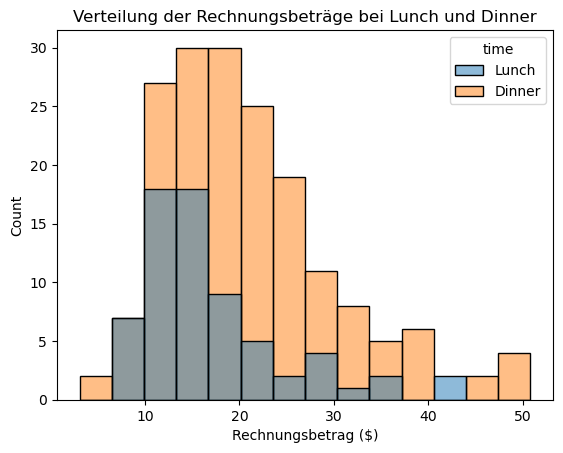

In [32]:
sns.histplot(data=df, x="total_bill", hue="time")
plt.title("Verteilung der Rechnungsbeträge bei Lunch und Dinner")
plt.xlabel("Rechnungsbetrag ($)")
plt.show()

## Hypothesentest

## Exkurs: Der t-Test

### 1. Ziel
Der t-Test prüft, ob sich die **Mittelwerte zweier Gruppen** einer stetigen Variable  
**signifikant unterscheiden**.

**Beispiel:**  
Unterscheiden sich die durchschnittlichen Rechnungsbeträge zwischen Mittag (`Lunch`) und Abend (`Dinner`)?

---

### 2. Grundidee
Wir vergleichen zwei Stichprobenmittelwerte:
$$
t = \frac{\bar{x}_1 - \bar{x}_2}{SE_{\text{Differenz}}}
$$

Der Nenner (Standardfehler der Differenz) berücksichtigt die **Streuung** und die **Stichprobengröße**.  
Je größer die Mittelwertdifferenz im Verhältnis zur Streuung, desto größer der t-Wert → desto unwahrscheinlicher, dass der Unterschied zufällig ist.

---

### 3. Hypothesen

- **H₀ (Nullhypothese):** Beide Gruppen haben **denselben Mittelwert**.  
  $$
  \mu_1 = \mu_2
  $$

- **H₁ (Alternativhypothese):** Die Mittelwerte **unterscheiden sich**.  
  $$
  \mu_1 \neq \mu_2
  $$

---

### 4. Entscheidung

- Wenn **p < 0.05** → H₀ verwerfen → der Unterschied ist **signifikant**.  
- Wenn **p ≥ 0.05** → H₀ beibehalten → kein signifikanter Unterschied.  

Ein signifikanter Unterschied bedeutet:  
→ Es ist **unwahrscheinlich**, dass die beobachtete Differenz nur durch Zufall entstanden ist.

---

### 5. Varianten des t-Tests

| Testart | Wann verwendet |
|----------|----------------|
| **Ein-Stichproben-t-Test** | Vergleich eines Mittelwerts mit einem festen Wert (z. B. „Durchschnitt = 15 % Trinkgeld?“) |
| **Unabhängiger t-Test** | Vergleich zweier Gruppen (z. B. Lunch vs. Dinner) |
| **Abhängiger t-Test** | Vergleich gepaarter Messungen (z. B. vorher/nachher bei denselben Personen) |

---

### 6. Voraussetzungen
- Die **abhängige Variable** ist **stetig**.  
- Die Gruppen sind **unabhängig** voneinander.  
- Die Daten in jeder Gruppe sind **annähernd normalverteilt**.  
- Die **Varianzen** sind ähnlich groß  
  → prüfen mit Levene-Test oder optisch per Boxplot.  

Falls Varianzen ungleich → **Welch-t-Test** verwenden (`equal_var=False`).  
Falls Normalverteilung stark verletzt → **Mann-Whitney-U-Test** als Alternative.

---

### 7. Kurz gesagt
Der t-Test prüft, ob der Unterschied zwischen zwei Mittelwerten  
**größer ist, als man durch Zufall erwarten würde**.  
Er beantwortet:  
> „Sind die Unterschiede zwischen den Gruppen **zufällig oder echt**?“


In [33]:
# Vergleich der Rechnungsbeträge zwischen Mittag und Abend

# 1. Teilstichproben bilden
lunch  = df.loc[df["time"] == "Lunch",  "total_bill"]
dinner = df.loc[df["time"] == "Dinner", "total_bill"]

# 2. t-Test für unabhängige Stichproben durchführen
t_stat, p_val = stats.ttest_ind(lunch, dinner, equal_var=True)

# 3. Effektstärke berechnen (Cohen's d)
def cohens_d(x1, x2):
    n1, n2 = len(x1), len(x2)
    s1, s2 = np.var(x1, ddof=1), np.var(x2, ddof=1)
    s_pooled = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
    return (np.mean(x1) - np.mean(x2)) / s_pooled

d = cohens_d(lunch, dinner)

# 4. Ergebnisse ausgeben
print(f"t = {t_stat:.2f}, p = {p_val:.4f}, Cohen's d = {d:.3f}")


t = -2.90, p = 0.0041, Cohen's d = -0.414


### Interpretation des t-Tests

Der t-Test vergleicht die **Mittelwerte zweier Gruppen** und liefert drei zentrale Kennzahlen:

- **t-Wert:** zeigt, wie stark sich die Mittelwerte unterscheiden – im Verhältnis zur Streuung.  
- **p-Wert:** gibt an, wie wahrscheinlich ein solcher Unterschied wäre, **wenn es in Wahrheit keinen echten Unterschied gäbe** (H₀ gilt).  
- **Cohen’s d:** misst die **Größe** des Unterschieds unabhängig von der Stichprobengröße.

#### Entscheidung und Interpretation
- **p < 0.05:** Unterschied ist **statistisch signifikant** → der Mittelwertunterschied ist sehr wahrscheinlich **nicht zufällig**.  
- **p ≥ 0.05:** kein signifikanter Unterschied → beobachtete Differenz kann **durch Zufall** erklärt werden.

#### Effektstärke (Cohen’s d)
Cohen’s *d* ergänzt die Signifikanz um eine Einschätzung der **praktischen Bedeutung** des Unterschieds.

| Betrag von d | Interpretation |
|---------------|----------------|
| 0.2 | kleiner Effekt |
| 0.5 | mittlerer Effekt |
| 0.8 | großer Effekt |tisch moderat bedeutsam**.



#### Beispiel: Lunch vs. Dinner (`total_bill`)
Ergebnis:  
`t = -2.90, p = 0.0041, d = -0.41`  
→ Der Unterschied zwischen Lunch und Dinner ist **signifikant** (p < 0.05)  
→ Die Effektstärke liegt im **mittleren Bereich** (|d| ≈ 0.4)  
→ Rechnungsbeträge am **Abend sind im Durchschnitt höher** als mittags.

**Fazit:**  
Der Unterschied ist sowohl **statistisch signifikant** als auch **praktisch moderat bedeutsam**.

## 5. Kombination 3: Zwei stetige Variablen
Beispiel: **`total_bill` ↔ `tip`**

**Fragestellung:**  
Besteht ein **linearer Zusammenhang** zwischen Rechnung und Trinkgeld?

---

### Warum ist das interessant?
Bei zwei stetigen Variablen interessiert, ob **mit steigenden Werten der einen**  
auch die andere Variable **systematisch mitsteigt oder sinkt**.  
→ z. B. Geben Gäste mit höherer Rechnung auch mehr Trinkgeld?

---

### Streudiagramm (Scatterplot)

```python
sns.scatterplot(x="total_bill", y="tip", data=df)
plt.title("Zusammenhang zwischen Rechnung und Trinkgeld")
plt.xlabel("Rechnungsbetrag ($)")
plt.ylabel("Trinkgeld ($)")
plt.show()


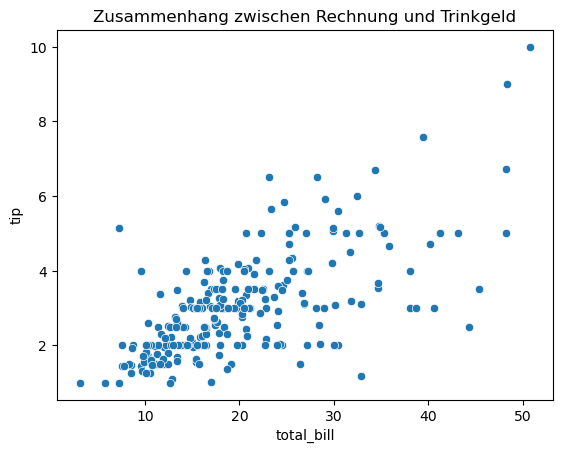

In [34]:
sns.scatterplot(x='total_bill', y='tip', data=df)
plt.title("Zusammenhang zwischen Rechnung und Trinkgeld")
plt.show()

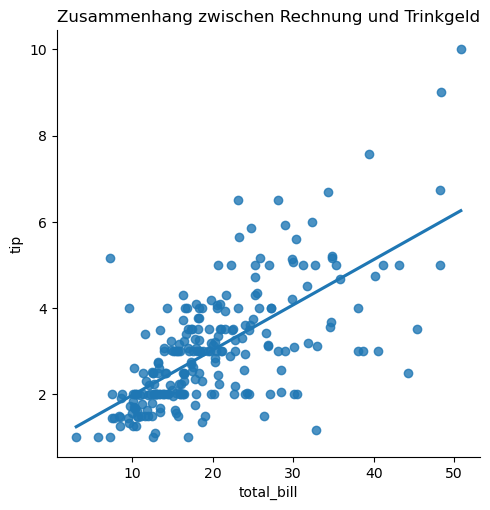

In [35]:
sns.lmplot(data=df, x="total_bill", y="tip", ci=None)
plt.title("Zusammenhang zwischen Rechnung und Trinkgeld")
plt.show()

### Interpretation des Streudiagramms

Jeder Punkt stellt eine Beobachtung dar (eine Rechnung und das dazugehörige Trinkgeld).

- Die Punkte bilden eine **aufsteigende Wolke** → es besteht ein **positiver Zusammenhang** zwischen Rechnung und Trinkgeld.  
- Je höher der **Rechnungsbetrag**, desto höher ist tendenziell auch das **Trinkgeld**.  
- Der Zusammenhang wirkt **annähernd linear** – das Trinkgeld steigt etwa proportional mit der Rechnung.  
- Die Streuung nimmt mit der Rechnung leicht zu: bei hohen Rechnungsbeträgen variieren die Trinkgelder stärker.  

**Fazit:**  
Gäste geben bei größeren Rechnungen im Durchschnitt auch mehr Trinkgeld. Das Diagramm zeigt also einen **klaren positiven linearen Zusammenhang** zwischen den beiden Variablen.

Die Regressionslinie bestätigt, dass zwischen `total_bill` und `tip` ein **deutlicher linearer Zusammenhang** besteht: höhere Rechnungen → höheres Trinkgeld.


## Hypothesentest

### Einführung: Pearson-Korrelation als Hypothesentest

Die **Pearson-Korrelation** misst, **wie stark und in welche Richtung** zwei stetige Variablen **linear miteinander zusammenhängen**.  
Sie liefert zwei Werte:

- **r** → den Korrelationskoeffizienten (zwischen -1 und +1)  
- **p** → den p-Wert zum Test der Signifikanz

---

### Ist das ein Hypothesentest?
Ja.  
Mit dem p-Wert wird die **Nullhypothese H₀: ρ = 0** (kein linearer Zusammenhang in der Grundgesamtheit) getestet.

\[
\begin{aligned}
H_0 &: \rho = 0 \quad \text{(kein Zusammenhang)} \\
H_1 &: \rho \neq 0 \quad \text{(es besteht ein Zusammenhang)}
\end{aligned}
\]

---

### Entscheidung
- **p < 0.05:** Der Zusammenhang ist **statistisch signifikant** → es besteht sehr wahrscheinlich ein **echter linearer Zusammenhang**.  
- **p ≥ 0.05:** Kein signifikanter Zusammenhang → die beobachtete Korrelation kann **durch Zufall** erklärt werden.

---

### Beispielergebnis
```python
r, p = stats.pearsonr(df["total_bill"], df["tip"])
print(f"r = {r:.3f}, p = {p:.4f}")


In [36]:
# Pearson-Korrelation
r, p = stats.pearsonr(df["total_bill"], df["tip"])
print(f"r = {r:.3f}, p = {p:.4f}")

r = 0.676, p = 0.0000


### Interpretation der Pearson-Korrelation (Allgemein)

Die Pearson-Korrelation beschreibt den **linearen Zusammenhang** zwischen zwei stetigen Variablen.

- **r-Wert:** misst Richtung und Stärke des Zusammenhangs.  
  - **r > 0** → positiver Zusammenhang (beide steigen gemeinsam)  
  - **r < 0** → negativer Zusammenhang (eine steigt, die andere sinkt)  
  - **|r| nahe 1** → starker Zusammenhang  
  - **|r| nahe 0** → schwacher oder kein linearer Zusammenhang  

- **p-Wert:** prüft, ob die beobachtete Korrelation **statistisch signifikant** ist.  
  - **p < 0.05** → H₀ (kein Zusammenhang) wird verworfen → der Zusammenhang ist **signifikant**.  
  - **p ≥ 0.05** → kein signifikanter Zusammenhang → beobachtete Korrelation kann **zufällig** sein.

**Wichtig:**  
Die Korrelation zeigt nur **gemeinsames Verhalten**, keine **Ursache-Wirkungs-Beziehung**

(Korrelation $\neq$ Kausalität).

### Beispiel: Rechnung und Trinkgeld (`total_bill` ↔ `tip`)

**Ergebnis:**  
`r = 0.676, p = 0.0000`

**Interpretation:**  
- **Richtung:** positiv → höhere Rechnungen gehen mit höheren Trinkgeldern einher.  
- **Stärke:** r ≈ 0.68 → deutlicher linearer Zusammenhang.  
- **Signifikanz:** p < 0.05 → Zusammenhang ist **statistisch signifikant**.  
- Die Punktwolke zeigt eine klar aufsteigende Struktur → lineare Beziehung plausibel.

**Fazit:**  
Es besteht ein **signifikanter positiver linearer Zusammenhang**:  
Je größer der Rechnungsbetrag, desto höher ist im Durchschnitt das Trinkgeld.

# 6. Zusammenfassung: Entscheidungslogik

Bitte ergänzen:

| Kombination | Diagramm | Test | Effektgröße |
|--------------|-----------|------|--------------|
| 2 kategoriale | Balken / Mosaik | Chi² | V |
| kategorial + stetig | Box / Violin | t-Test | d |
| 2 stetige | Scatterplot | Pearson | r |

Schritte:
1. Variablentypen bestimmen  
2. Visualisierung wählen  
3. Annahmen prüfen  
4. Test anwenden  
5. Effektgröße berechnen  
6. Ergebnis berichten